In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [31]:
#1. EDA

In [32]:
#Load the dataset
df = pd.read_csv("/content/Pharma_Industry (1).csv")
df

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1
...,...,...,...,...,...,...
495,-1.553759,0.506938,0.817890,-0.661245,-1.345393,0
496,0.551476,1.714321,0.340589,1.712558,-0.496315,1
497,-1.072743,-0.221137,0.239247,1.112924,-0.285838,1
498,1.661259,0.245759,-0.457096,0.633355,0.657413,0


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [34]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [35]:
df.dtypes

,0
Drug Dosage (mg),float64
Systolic Blood Pressure (mmHg),float64
Heart Rate (BPM),float64
Liver Toxicity Index (U/L),float64
Blood Glucose Level (mg/dL),float64
Drug Response,int64


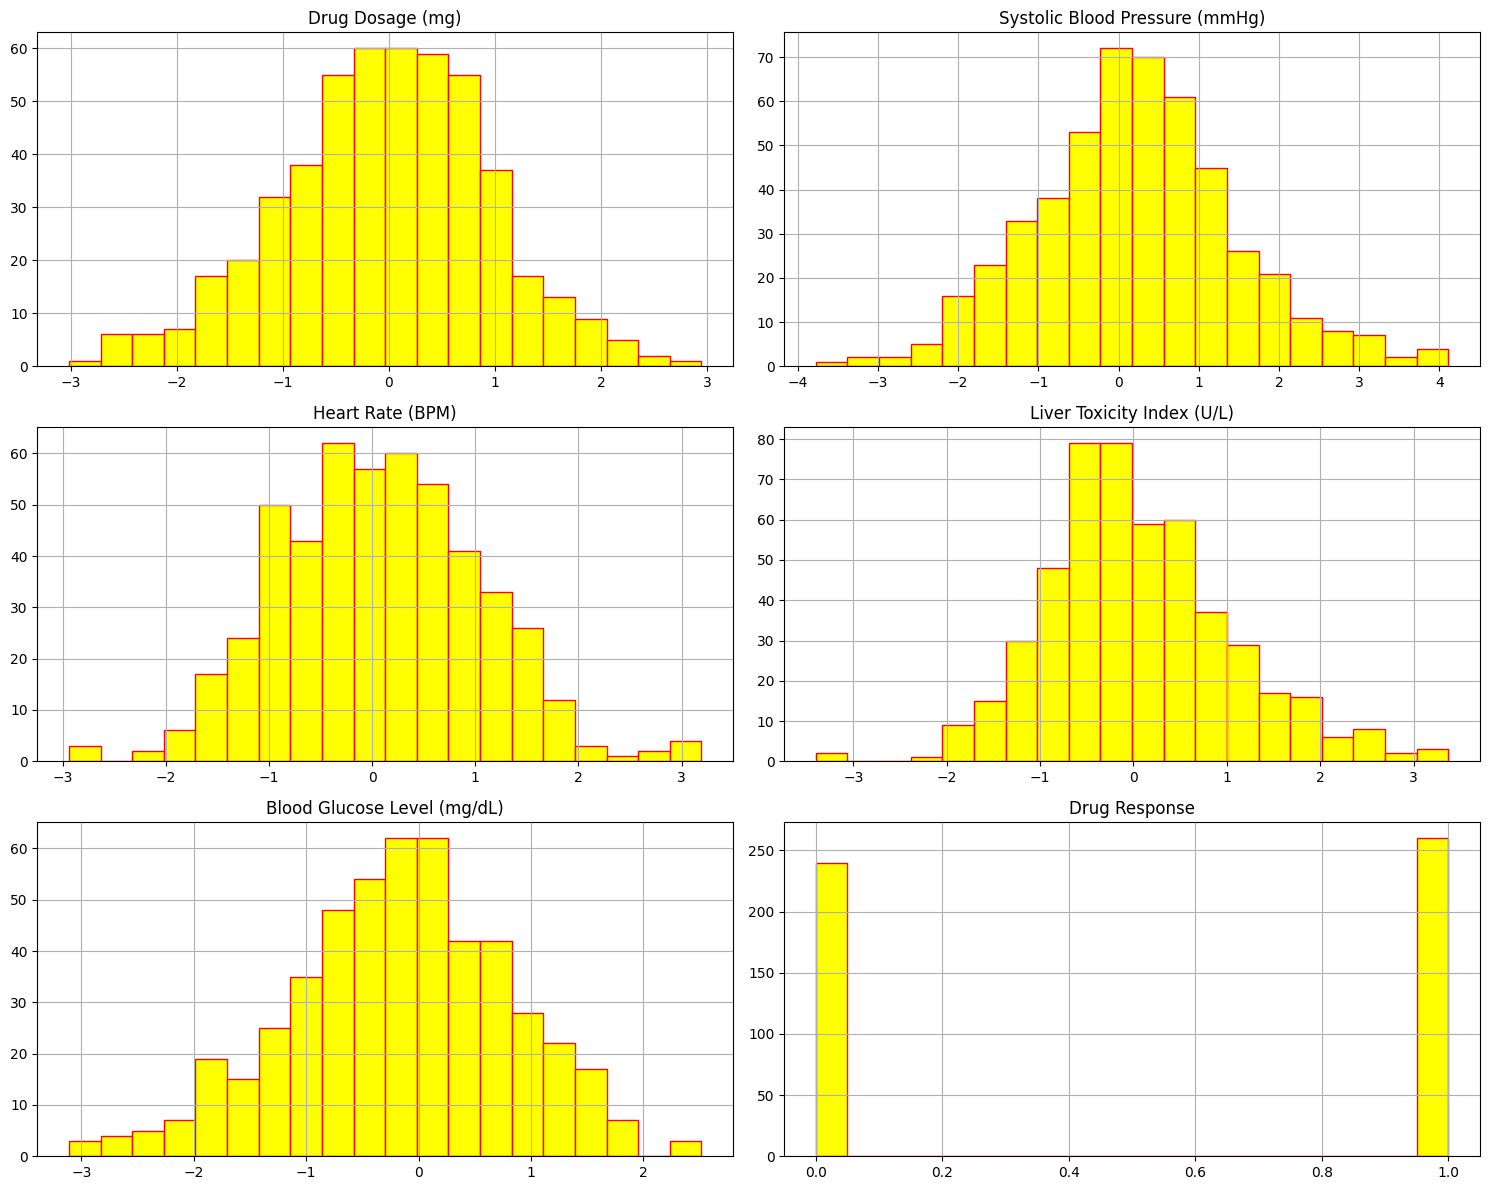

In [36]:
#2.Utilize histograms, box plots, or density plots to understand feature distributions.
#Histograms
df.hist(figsize=(15,12),facecolor="yellow",edgecolor="red",bins=20)
plt.tight_layout()
plt.show()

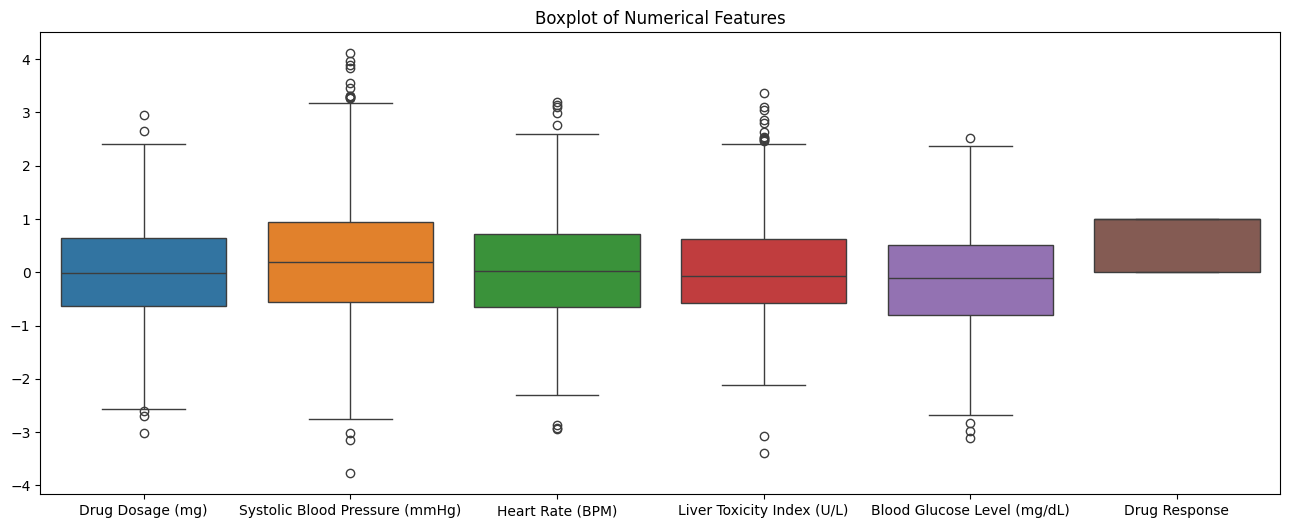

In [37]:
# Box Plots
plt.figure(figsize=(16, 6))
sns.boxplot(data=df)
plt.title("Boxplot of Numerical Features")
plt.show()

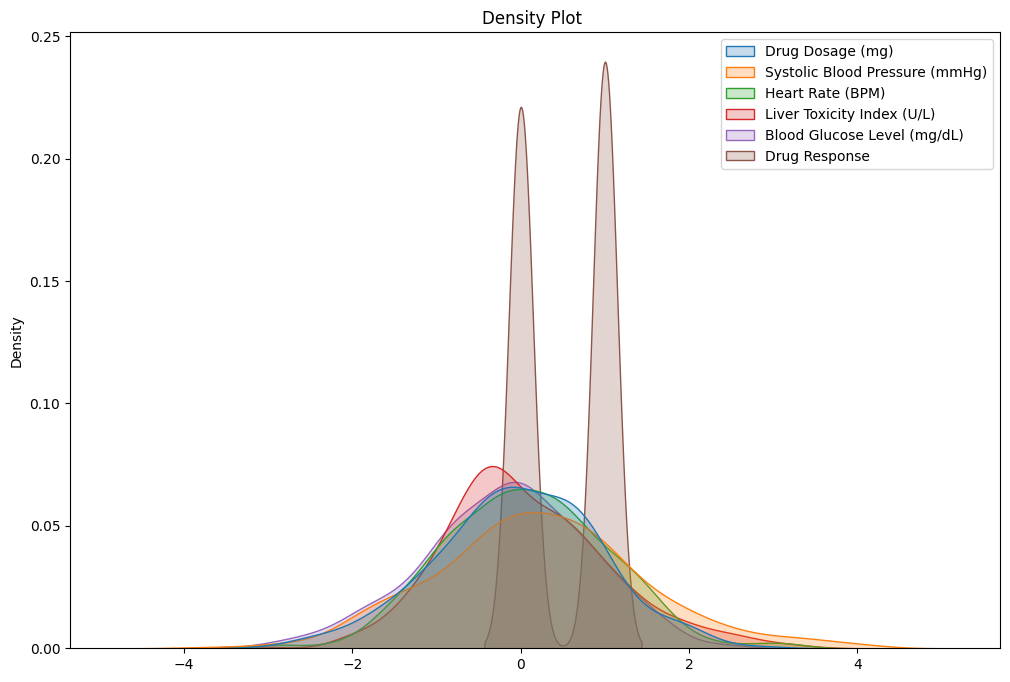

In [38]:
#density plot
plt.figure(figsize=(12, 8))
sns.kdeplot(df, fill=True,color='green')
plt.title("Density Plot ")
plt.show()

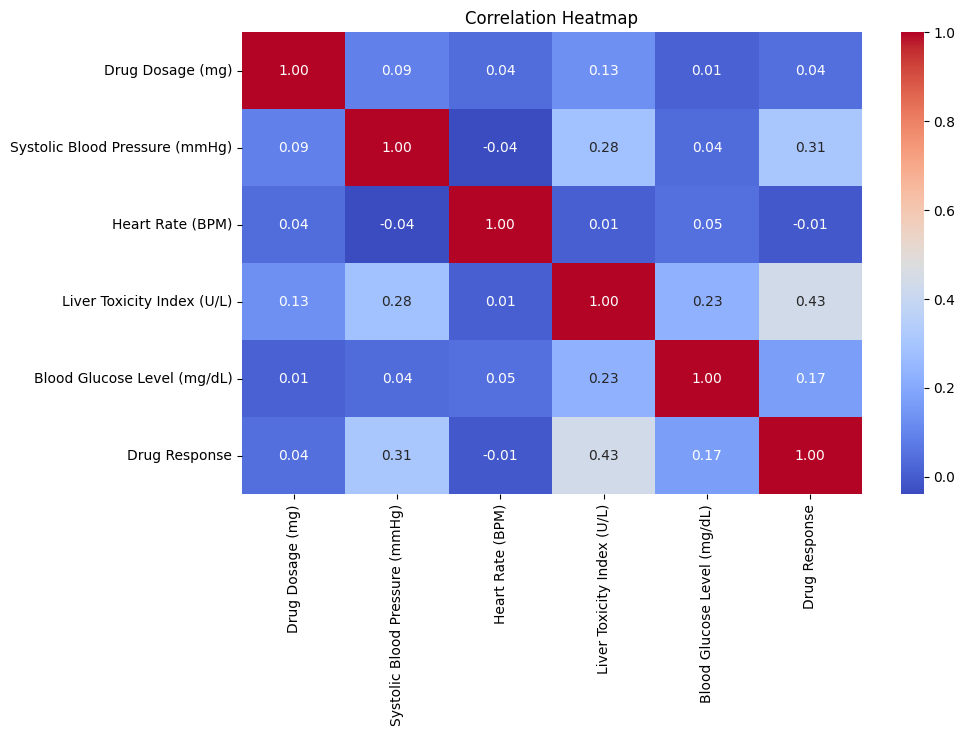

In [39]:
#3. Investigate feature correlations to discern relationships within the data.
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [40]:
#2. Data Preprocessing

In [41]:
#1. Encode categorical variables if necessary.
df.dtypes

# No Categorical Variable present in the dataset , so no need to use the Encodeing

,0
Drug Dosage (mg),float64
Systolic Blood Pressure (mmHg),float64
Heart Rate (BPM),float64
Liver Toxicity Index (U/L),float64
Blood Glucose Level (mg/dL),float64
Drug Response,int64


In [42]:

#2.	Split the dataset into training and testing sets.
from sklearn.model_selection import train_test_split
X = df[["Drug Dosage (mg)", "Systolic Blood Pressure (mmHg)", "Heart Rate (BPM)", "Liver Toxicity Index (U/L)", "Blood Glucose Level (mg/dL)"]]
y = df["Drug Response"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
#3. Data visualization

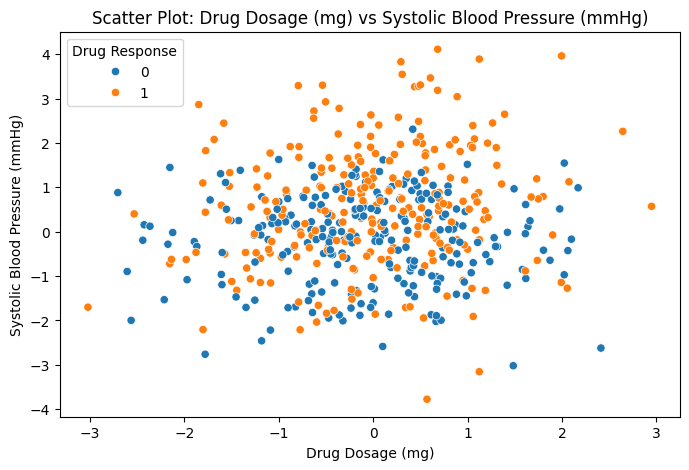

In [44]:
#1. Employ scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships.
#scatter plot between 'Drug Dosage (mg)' and 'Systolic Blood Pressure (mmHg)'
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Drug Dosage (mg)', y='Systolic Blood Pressure (mmHg)', data=df, hue='Drug Response')
plt.title("Scatter Plot: Drug Dosage (mg) vs Systolic Blood Pressure (mmHg)")
plt.show()

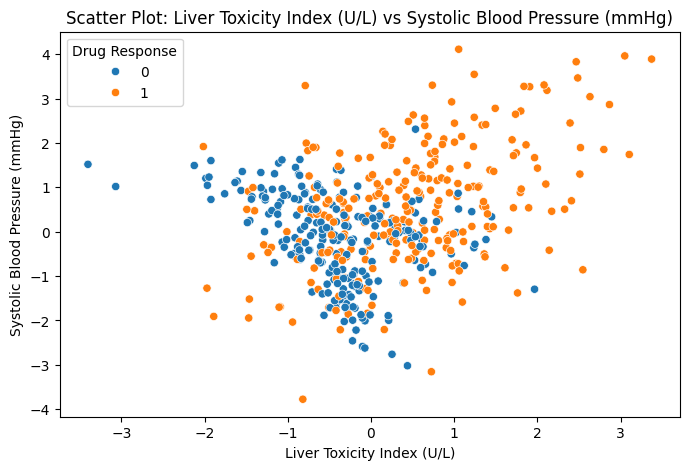

In [45]:
#scatter plot between 'Liver Toxicity Index (U/L)' and 'Systolic Blood Pressure (mmHg)'
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Liver Toxicity Index (U/L)', y='Systolic Blood Pressure (mmHg)', data=df, hue='Drug Response')
plt.title("Scatter Plot: Liver Toxicity Index (U/L) vs Systolic Blood Pressure (mmHg)")
plt.show()

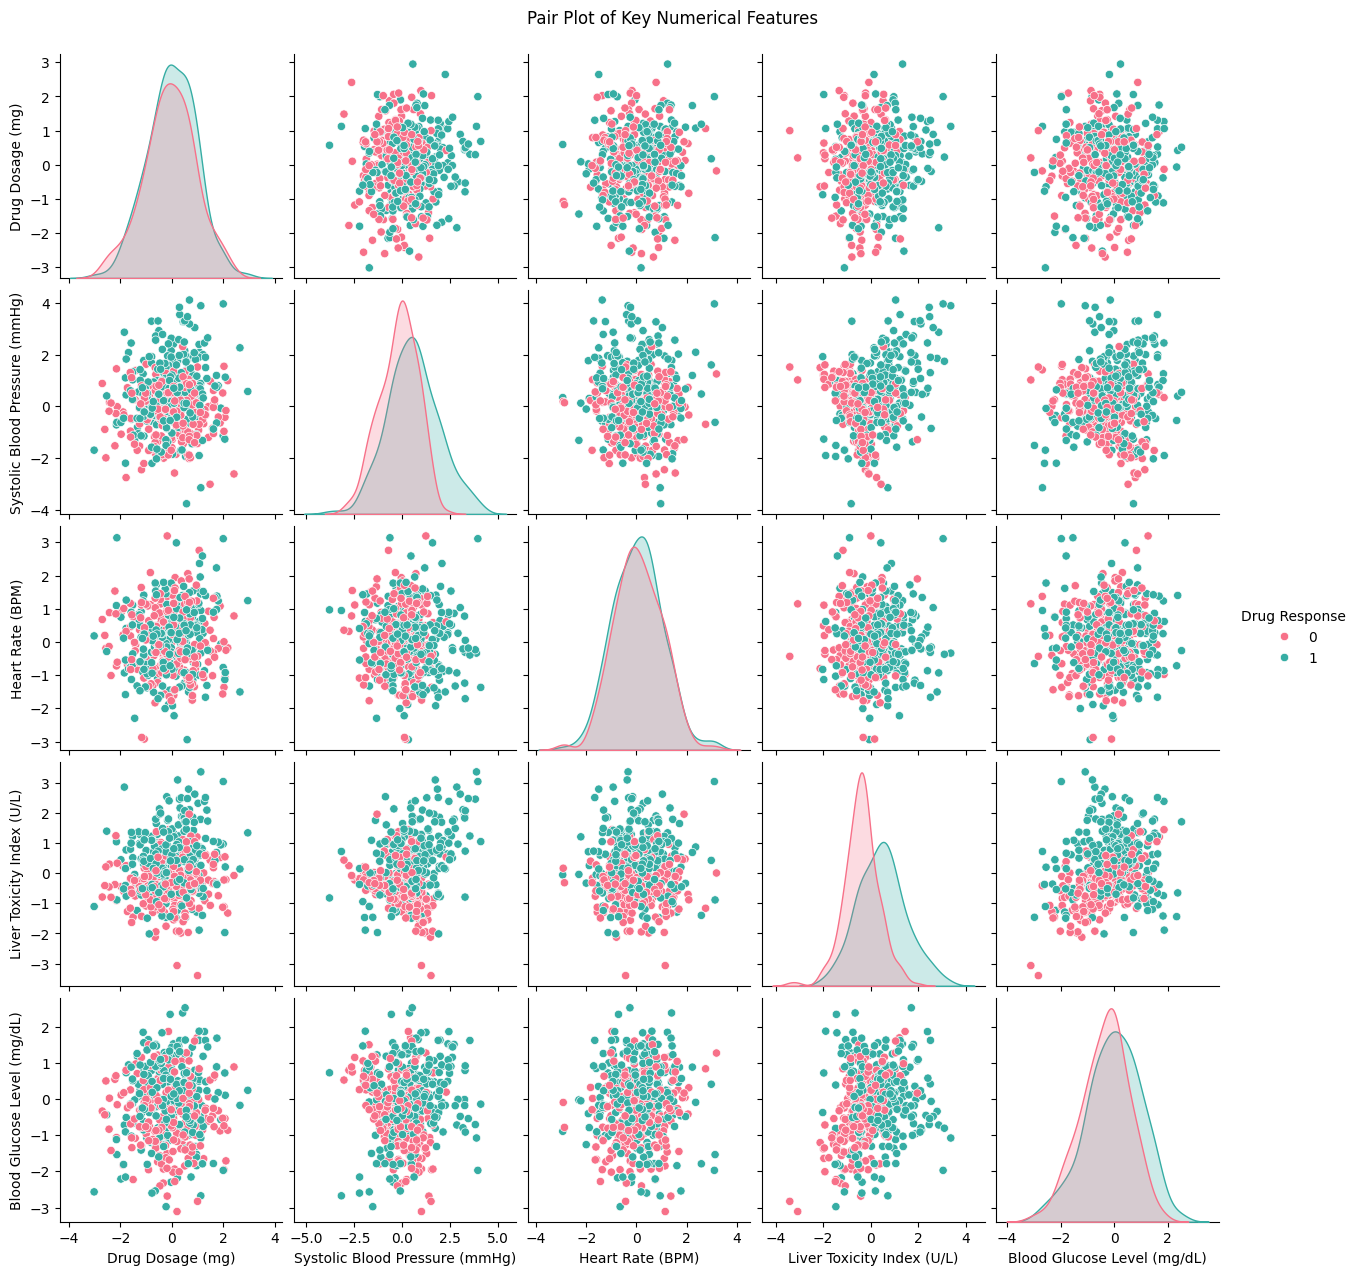

In [46]:
# Pair Plot for selected features
selected_features = ['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
                     'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
                     'Blood Glucose Level (mg/dL)', 'Drug Response']
sns.pairplot(df[selected_features], hue='Drug Response', diag_kind='kde', palette='husl')
plt.suptitle("Pair Plot of Key Numerical Features", y=1.02)
plt.show()

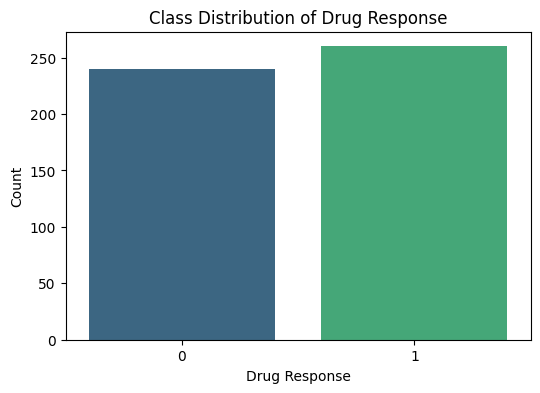

In [47]:
#2. Visualize class distributions to gauge dataset balance or imbalance.
plt.figure(figsize=(6,4))
sns.countplot(x='Drug Response',hue='Drug Response', legend=False, data=df, palette='viridis')
plt.title('Class Distribution of Drug Response')
plt.xlabel('Drug Response')
plt.ylabel('Count')
plt.show()

In [48]:
#4. SVM

In [49]:
#1.	Implement a basic SVM classifier using Python libraries like scikit-learn.
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [50]:
#2.	Train the SVM model on the training data.
model = SVC(kernel='linear')
model.fit(X_train,y_train)

SVC(kernel='linear')

In [51]:
#3.	Evaluate model performance on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score).
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

accuracy_score_train = accuracy_score(y_train, y_pred_train)
accuracy_score_test = accuracy_score(y_test, y_pred_test)

precision_score_train = precision_score(y_train, y_pred_train)
precision_score_test = precision_score(y_test, y_pred_test)

recall_score_train = recall_score(y_train, y_pred_train)
recall_score_test = recall_score(y_test, y_pred_test)

f1_score_train = f1_score(y_train, y_pred_train)
f1_score_test = f1_score(y_test, y_pred_test)

print("accuracy_score_train:",accuracy_score_train)
print("accuracy_score_test:",accuracy_score_test)
print("precision_score_train:",precision_score_train)
print("precision_score_test:",precision_score_test)
print("recall_score_train:",recall_score_train)
print("recall_score_test:",recall_score_test)
print("f1_score_train:",f1_score_train)
print("f1_score_test:",f1_score_test)

accuracy_score_train: 0.71
accuracy_score_test: 0.78
precision_score_train: 0.7588235294117647
precision_score_test: 0.84
recall_score_train: 0.6323529411764706
recall_score_test: 0.75
f1_score_train: 0.6898395721925134
f1_score_test: 0.7924528301886793


In [52]:
#5. Visualization of SVM Results

In [53]:
from scipy.spatial import Delaunay

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


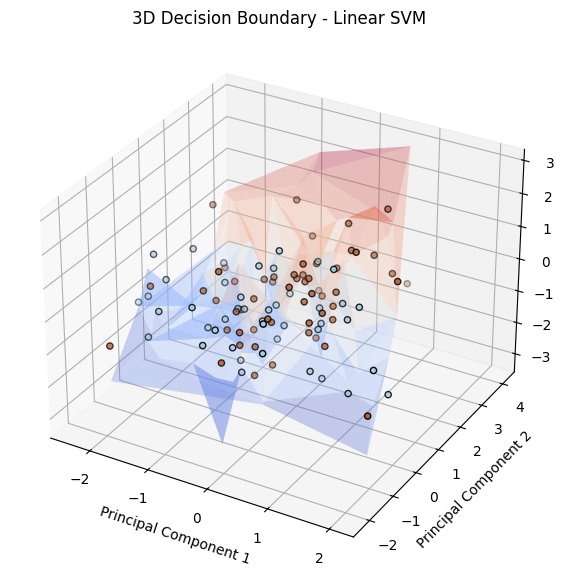

In [54]:
#1.	Visualize classification results on the testing data.
def plot_3d_decision_boundary_fixed(model, X, y, title):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Scatter plot of data points
    ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap=plt.cm.Paired, edgecolor='k')

    # Create a triangulation of the feature space
    tri = Delaunay(X[:, :2])

    # Predict values for the 3D surface
    Z = model.decision_function(X)

    # Create surface plot
    ax.plot_trisurf(X[:, 0], X[:, 1], Z, triangles=tri.simplices, cmap='coolwarm', alpha=0.3)

    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.set_zlabel('Decision Boundary')
    ax.set_title(title)

    plt.show()

%matplotlib inline
plot_3d_decision_boundary_fixed(model, X_test.values, y_test, "3D Decision Boundary - Linear SVM")

In [55]:
#6. Parameter Tuning and Optimization

In [56]:
#1.	Experiment with different SVM hyperparameters (e.g., kernel type, regularization parameter) to optimize performance.

svm_linear = SVC(kernel='linear', C=1.0)
svm_poly = SVC(kernel='poly', degree=1, C=2.0)
svm_rbf = SVC(kernel='rbf', gamma=1, C=1.0)

# Train and evaluate SVM with linear kernel
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)
accuracy_linear = accuracy_score(y_test, y_pred_linear)

# Train and evaluate SVM with polynomial kernel
svm_poly.fit(X_train, y_train)
y_pred_poly = svm_poly.predict(X_test)
accuracy_poly = accuracy_score(y_test, y_pred_poly)

# Train and evaluate SVM with RBF kernel
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)

# Display results
print("Linear SVM Accuracy:", accuracy_linear)
print("Polynomial SVM Accuracy:", accuracy_poly)
print("RBF SVM Accuracy:",accuracy_rbf)

Linear SVM Accuracy: 0.78
Polynomial SVM Accuracy: 0.78
RBF SVM Accuracy: 0.78


In [57]:
#7. Comparison and Analysis

In [58]:
#1.	Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).
kernels = ['linear', 'poly', 'rbf']
results = []

for kernel in kernels:
    svm_model = SVC(kernel=kernel, random_state=42)
    svm_model.fit(X_train, y_train)

    y_pred = svm_model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([kernel, accuracy, precision, recall, f1])

svm_results = pd.DataFrame(results, columns=['Kernel', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
print(svm_results)

   Kernel  Accuracy  Precision    Recall  F1-Score
0  linear      0.78   0.840000  0.750000  0.792453
1    poly      0.69   0.857143  0.535714  0.659341
2     rbf      0.82   0.865385  0.803571  0.833333


In [59]:
#2.	Analyze SVM strengths and weaknesses for the dataset based on EDA and visualization results.

# The Data shows moderate class separation with some overlapping regions. SVM strengths lie in handling non-linear
# patterns effectively like RDF kernel and maintaining good generalization. its weaknesses include sensitivity to
# overlapping classes and the nedd fro careful kernel.

In [60]:
#3.	Discuss practical implications of SVM in real-world classification tasks.

# SVM are effective for high dimensional data and clear class boundaries, making them useful in text, image, and
# medical classification, but they can be slow and sensitive to noise on large or overlapping datasets.